# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

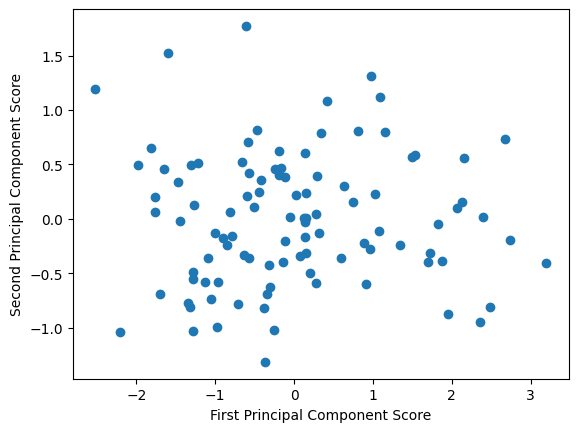

In [1]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

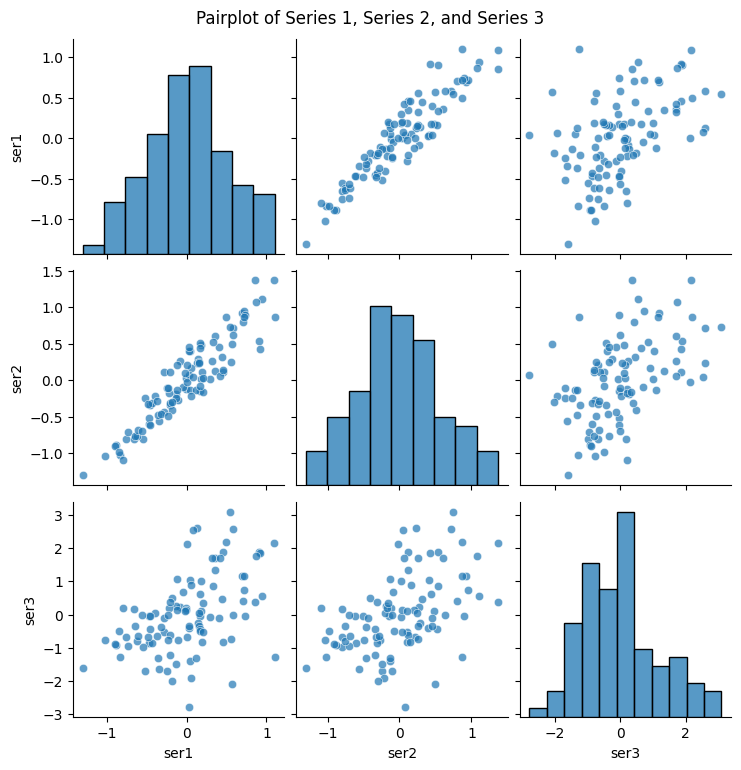

In [3]:
import seaborn as sns

# Plot pairplot
sns.pairplot(df, kind="scatter", plot_kws={'alpha': 0.7})
plt.suptitle("Pairplot of Series 1, Series 2, and Series 3", y=1.02)
plt.show()

ANSWER:

The upper-left outliers in the PCA plot likely have high series_3 values but low shared structure (series_1 and series_2). They seem to have relatively low first component scores and relative high second component scores meaning that most of their shared variance is attributable to the variance not captured by the shared variance of series one and two's collinearity. PCA does flip the axis of the data, so it is not directly interpretable in the context of understanding the direct relationships of the series' themselves. That is where the pairplot supports our interpretation. 

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [4]:
# Dataset 1: MEPS HC-244: MEPS Panel 26 Two-Year Longitudinal Data File
meps = pd.read_csv("~/Documents/AIforLeaders/Milestone3_Datasets/h244.csv")

# Define the list of 50 selected variables
selected_columns = [
    "DUPERSID", "CHDDXY1", "CHDDXY2", "CHDAGY1", "CHDAGY2", "MIDXY1", "MIDXY2", "MIAGY1", "MIAGY2",
    "ANGIDXY1", "ANGIDXY2", "ANGIAGY1", "ANGIAGY2", "OHRTDXY1", "OHRTDXY2", "OHRTAGY1", "OHRTAGY2",
    "STRKDXY1", "STRKDXY2", "STRKAGY1", "STRKAGY2", "OPDEXPY1", "OPDEXPY2", "OPDMCDY1", "OPDMCDY2",
    "OPDMCRY1", "OPDMCRY2", "OPDPRVY1", "OPDPRVY2", "OPDSLFY1", "OPDSLFY2", "OPDVAY1", "OPDVAY2",
    "OPDOFDY1", "OPDOFDY2", "TOTEXPY1", "TOTEXPY2", "TOTSLFY1", "TOTSLFY2", "TOTMCRY1", "TOTMCRY2",
    "TOTMCDY1", "TOTMCDY2", "TOTPRVY1", "TOTPRVY2", "TOTVAY1", "TOTVAY2", "TOTTRIY1", "TOTTRIY2",
    "TOTTCHY1", "TOTTCHY2"
]
# Filter the dataframe to keep only selected variables
meps = meps[selected_columns].copy()

# convert categorical variables from numeric
meps["DUPERSID"] = meps["DUPERSID"].astype("category")
meps["CHDDXY1"] = meps["CHDDXY1"].astype("category")
meps["CHDDXY2"] = meps["CHDDXY2"].astype("category")
meps["MIDXY1"] = meps["MIDXY1"].astype("category")
meps["MIDXY2"] = meps["MIDXY2"].astype("category")
meps["ANGIDXY1"] = meps["ANGIDXY1"].astype("category")
meps["ANGIDXY2"] = meps["ANGIDXY2"].astype("category")
meps["OHRTDXY1"] = meps["OHRTDXY1"].astype("category")
meps["OHRTDXY2"] = meps["OHRTDXY2"].astype("category")
meps["STRKDXY1"] = meps["STRKDXY1"].astype("category")
meps["STRKDXY2"] = meps["STRKDXY2"].astype("category")
meps["OPDOFDY1"] = meps["OPDOFDY1"].astype("category")
meps["OPDOFDY2"] = meps["OPDOFDY2"].astype("category")

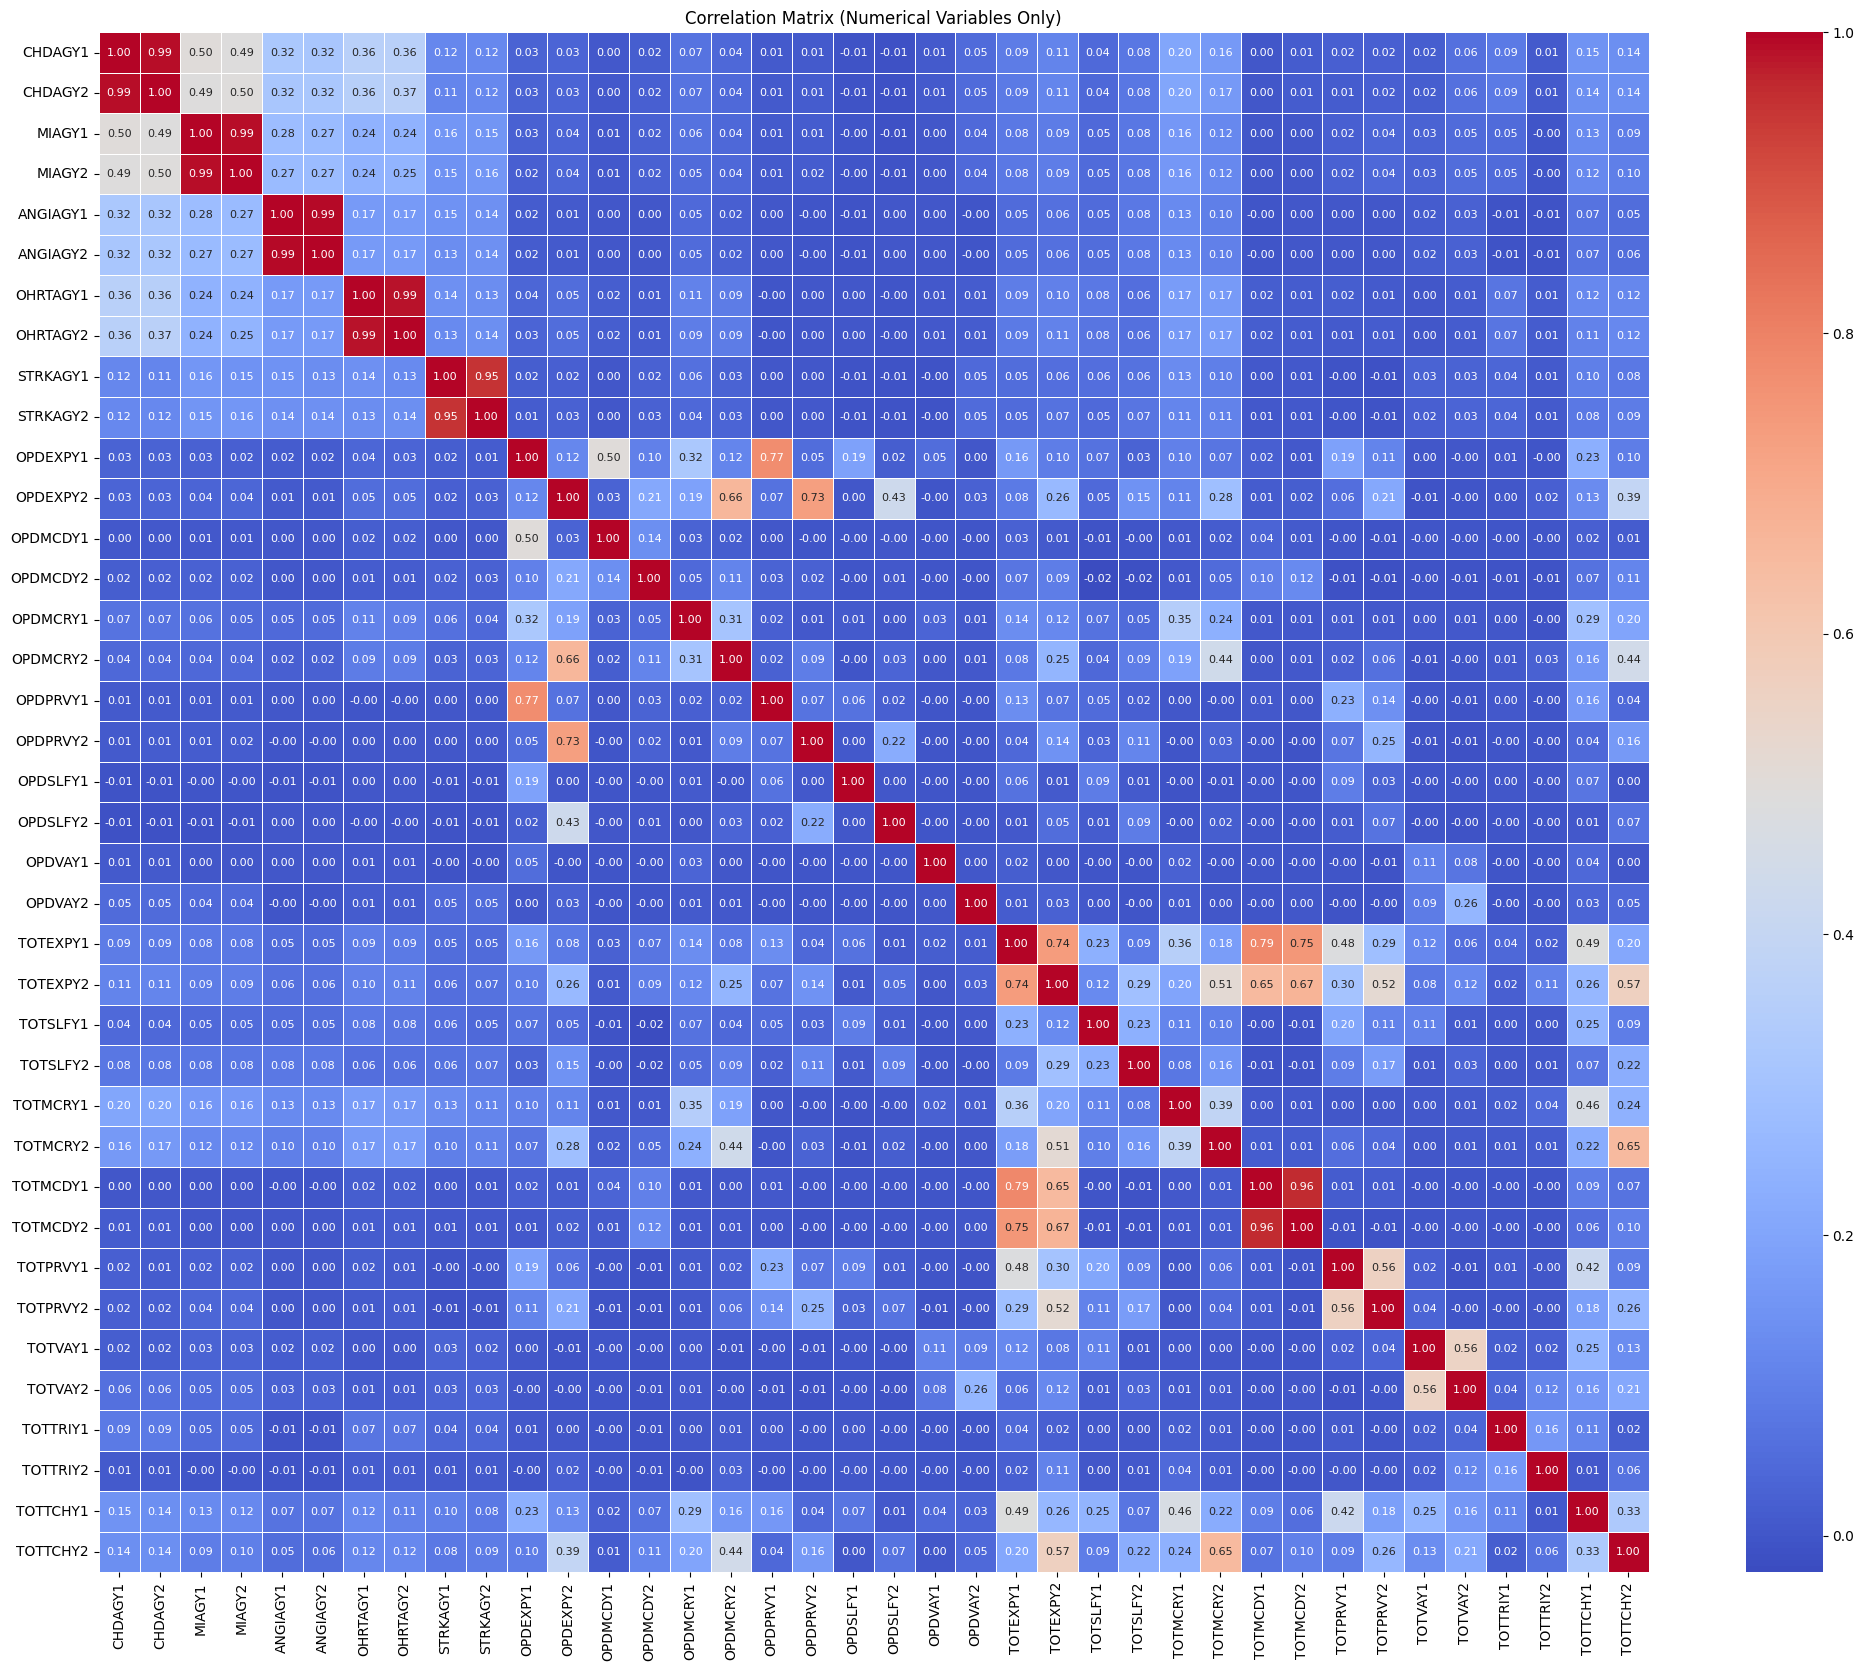

In [5]:
numerical_meps = meps.select_dtypes(include=['number'])  # Filters only numeric columns

# Compute correlation matrix
correlation_matrix = numerical_meps.corr()

# Plot the heatmap
plt.figure(figsize=(25, 20))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", 
            linewidths=0.5, annot_kws={"size": 8})
plt.xticks(rotation=90)
plt.title("Correlation Matrix (Numerical Variables Only)")
plt.show()

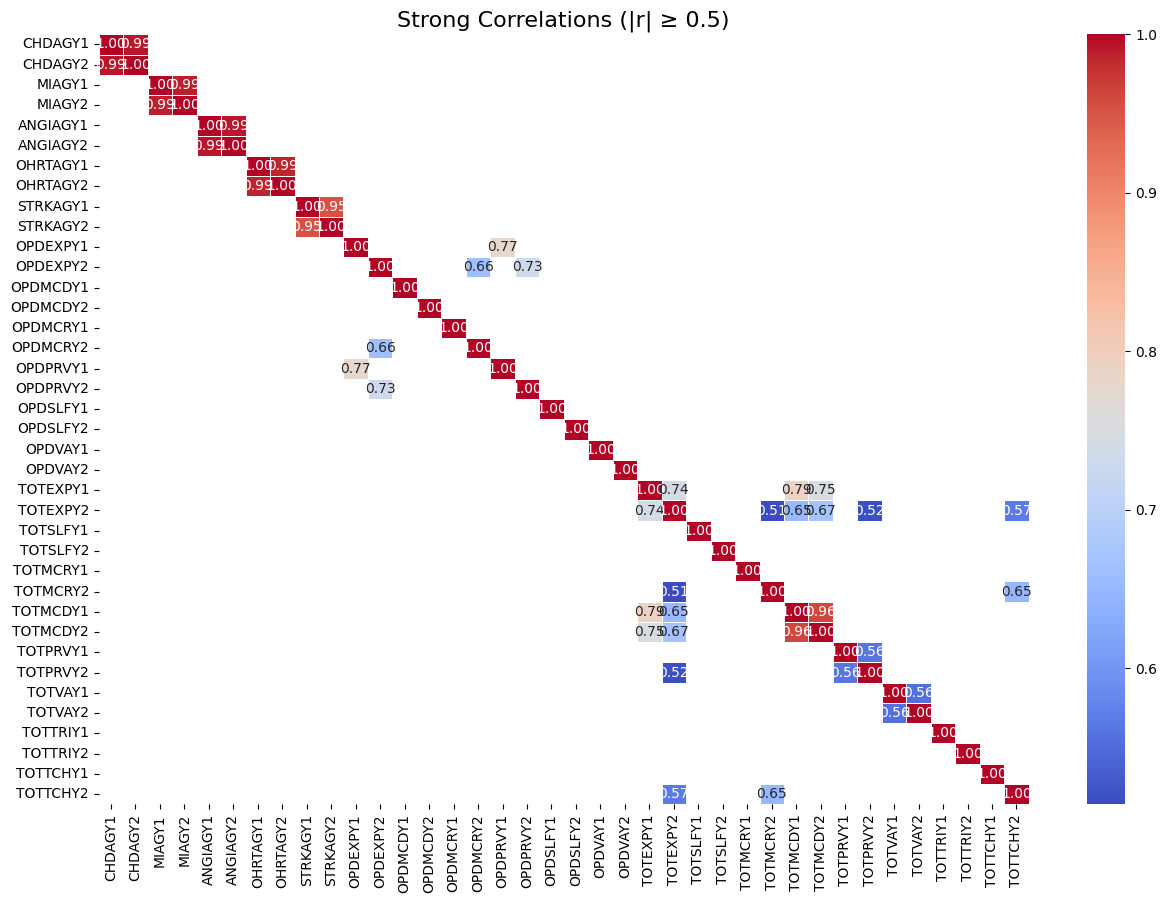

In [6]:
strong_corr = correlation_matrix[(correlation_matrix >= 0.5) | (correlation_matrix <= -0.5)]
plt.figure(figsize=(15, 10))
sns.heatmap(strong_corr, annot=True, fmt=".2f", cmap="coolwarm", 
            linewidths=0.5, annot_kws={"size": 10})
plt.title("Strong Correlations (|r| ≥ 0.5)", fontsize=16)
plt.show()

In the MEPS dataset, 9 of the strong correlations are between the first and second timepoints of the same variable. After removing those instances, there are still 11 correlations with an absolute value above 0.5. Filtering further to 0.7, we still have 4 correlations. Note: the numbers are halved from the table lengths because each variable combination is represented twice (Var1 vs Var2, Var2 vs Var1). 

/var/folders/w7/9y5zf9zx03j_jm3t98j7qmvc0000gp/T/ipykernel_41014/812731872.py:16: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.scatterplot(
/Users/ez873/jupyter_env/lib/python3.12/site-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


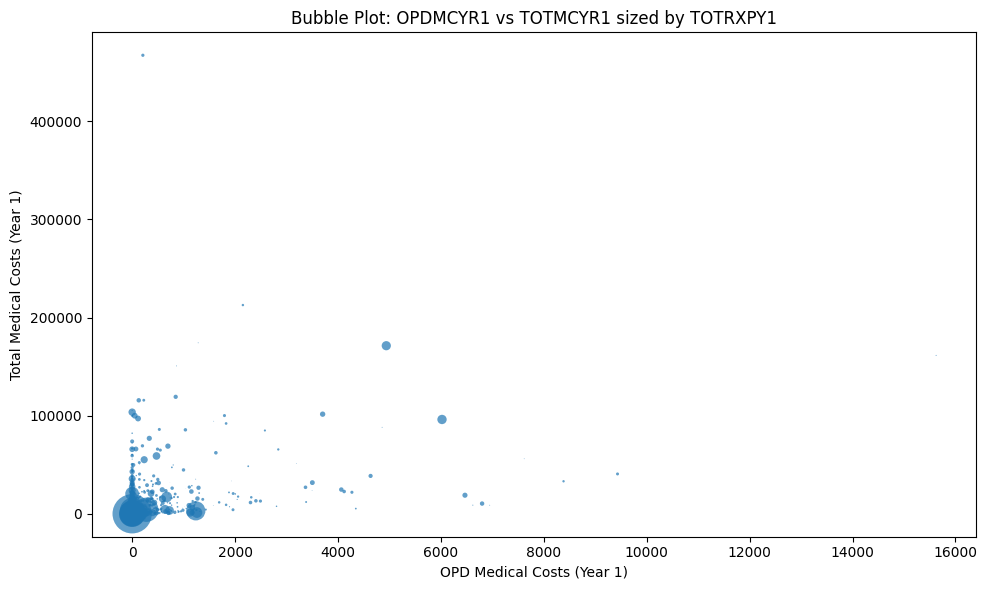

In [8]:
# Select the three interesting columns from the correlation heatmap
x_col = "OPDMCRY1"   # x-axis
y_col = "TOTMCRY1"   # y-axis
size_col = "TOTPRVY1"  # bubble size

# Drop rows with missing values in selected columns
bubble_data = numerical_meps[[x_col, y_col, size_col]].dropna()

# Define bubble size scaling
maxbubble = 800
min_size = bubble_data[size_col].min()
max_size = bubble_data[size_col].max()

# Create the plot
plt.figure(figsize=(10, 6))
ax = sns.scatterplot(
    data=bubble_data,
    x=x_col,
    y=y_col,
    size=size_col,
    sizes=(min_size / max_size * maxbubble, maxbubble),
    alpha=0.7,
    palette="viridis",
    legend=False
)

# Axis labels and title
ax.set_xlabel("OPD Medical Costs (Year 1)")
ax.set_ylabel("Total Medical Costs (Year 1)")
plt.title("Bubble Plot: OPDMCYR1 vs TOTMCYR1 sized by TOTRXPY1")
plt.tight_layout()
plt.show()

This bubble plot demonstrates pretty clearly both that there are outliers and that most data falls within a pretty narrow portion of the overall range.

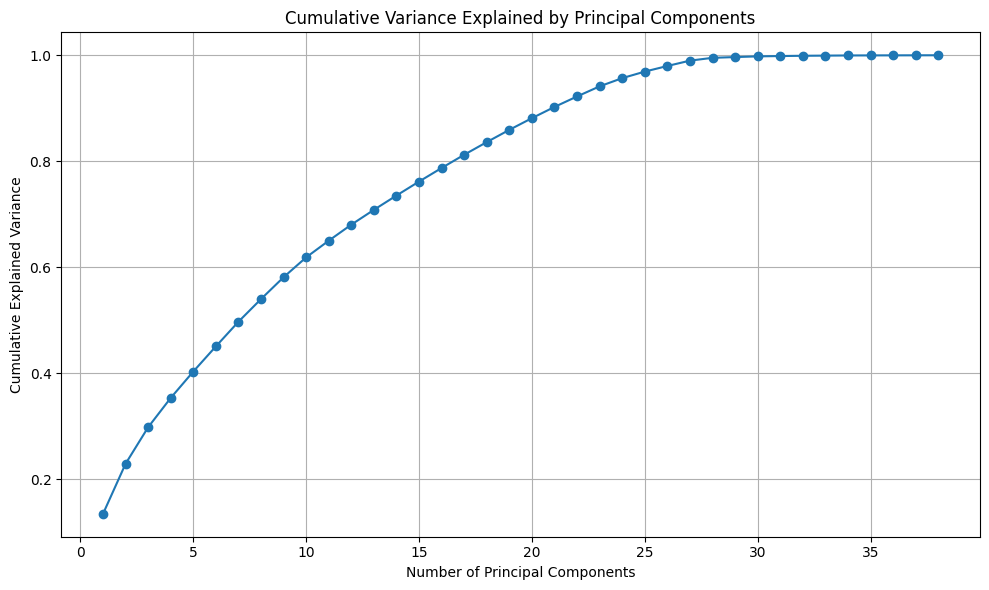

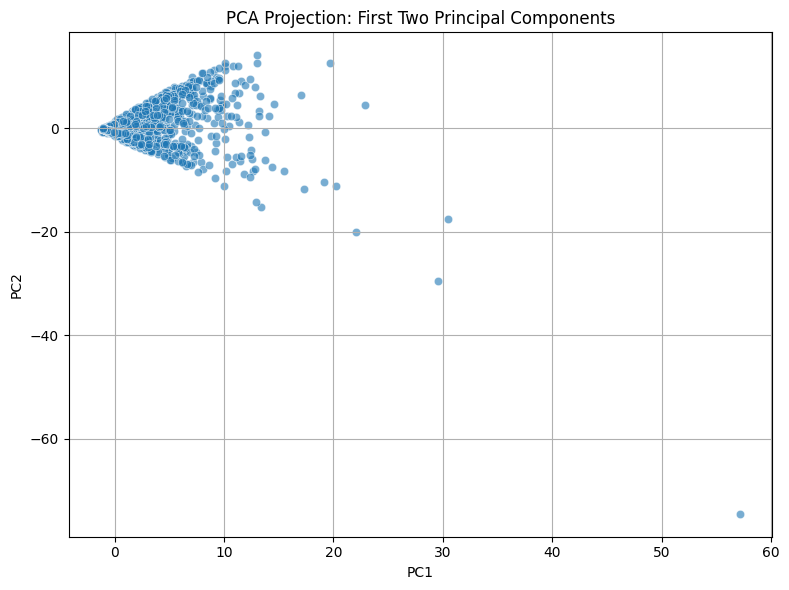

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
scaled_data = scaler.fit_transform(numerical_meps)

# Run PCA
pca = PCA()
pca.fit(scaled_data)

# Explained variance
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Plot explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_var) + 1), cumulative_var, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Variance Explained by Principal Components")
plt.grid(True)
plt.tight_layout()
plt.show()

# Optional: Project to first 2 components and visualize
pc_scores = pca.transform(scaled_data)
df_pca = pd.DataFrame(pc_scores[:, :2], columns=["PC1", "PC2"])

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", alpha=0.6)
plt.title("PCA Projection: First Two Principal Components")
plt.grid(True)
plt.tight_layout()
plt.show()

Despite the large number of variables in the dataset, most of the variance can be explained by relatively few components. PC1 alone explains a significant portion (possibly ~15%). The top 15 components explain roughly 70–80% of the variance. ~25 components are enough to capture ~95% of the variance supporting dimensionality reduction. The spread in the second plot suggests that there are outliers in the data that should be addressed. 

                            OLS Regression Results                            
Dep. Variable:               TOTEXPY1   R-squared:                       0.621
Model:                            OLS   Adj. R-squared:                  0.620
Method:                 Least Squares   F-statistic:                 1.102e+04
Date:                Sun, 06 Apr 2025   Prob (F-statistic):               0.00
Time:                        18:47:57   Log-Likelihood:                -76859.
No. Observations:                6741   AIC:                         1.537e+05
Df Residuals:                    6739   BIC:                         1.537e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       7371.5113    264.013     27.921      0.0

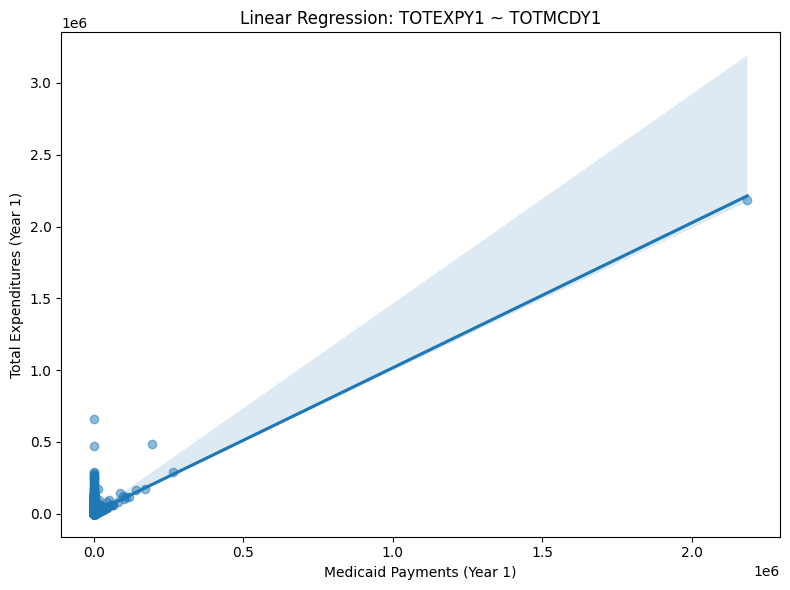

In [16]:
import statsmodels.api as sm

# Select the two variables of interest and drop missing values
df = meps[["TOTEXPY1", "TOTMCDY1"]].dropna()

# Define response (y) and predictor (X)
X = df["TOTMCDY1"]
y = df["TOTEXPY1"]

# Add constant term for intercept
X_with_const = sm.add_constant(X)

# Fit the linear regression model
model = sm.OLS(y, X_with_const).fit()

# Print the model summary
print(model.summary())

# Plot the data and regression line
plt.figure(figsize=(8, 6))
sns.regplot(x="TOTMCDY1", y="TOTEXPY1", data=df, scatter_kws={'alpha':0.5})
plt.xlabel("Medicaid Payments (Year 1)")
plt.ylabel("Total Expenditures (Year 1)")
plt.title("Linear Regression: TOTEXPY1 ~ TOTMCDY1")
plt.tight_layout()
plt.show()

In the linear regression we can see a crazy high outlier that drives the outcome. Removal of this data point will help clarify the pattern in the relationship between these two highly correlated variables. 

                            OLS Regression Results                            
Dep. Variable:               TOTEXPY1   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     166.7
Date:                Sun, 06 Apr 2025   Prob (F-statistic):           1.12e-37
Time:                        20:29:49   Log-Likelihood:                -71528.
No. Observations:                6614   AIC:                         1.431e+05
Df Residuals:                    6612   BIC:                         1.431e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5863.6595    152.331     38.493      0.0

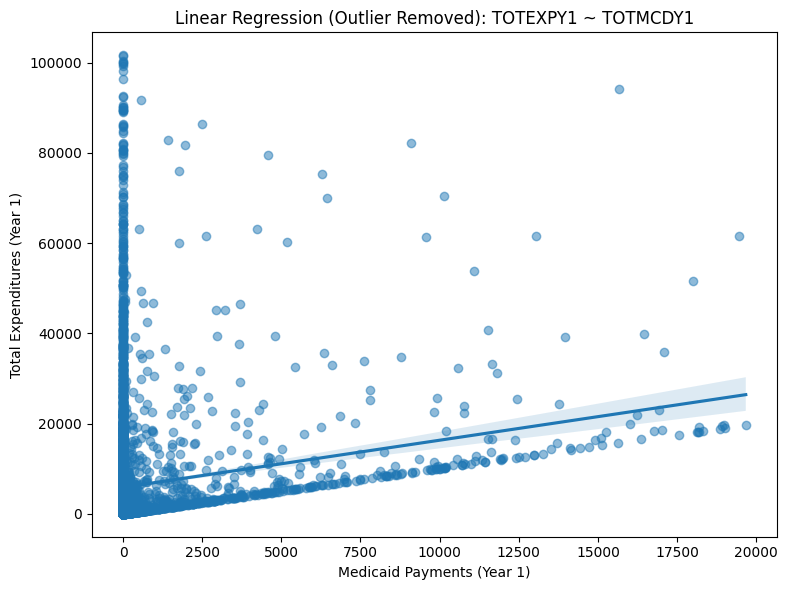

In [17]:
# Select relevant variables and drop missing data
df = meps[["TOTEXPY1", "TOTMCDY1"]].dropna()

# Option 1: Simple outlier removal using a threshold
# Remove rows where TOTMCDY1 or TOTEXPY1 > 99th percentile
q = 0.99
filtered_df = df[
    (df["TOTMCDY1"] < df["TOTMCDY1"].quantile(q)) &
    (df["TOTEXPY1"] < df["TOTEXPY1"].quantile(q))
]

# Define X and y for regression
X = filtered_df["TOTMCDY1"]
y = filtered_df["TOTEXPY1"]

# Add constant for intercept
X_with_const = sm.add_constant(X)

# Rerun linear regression
model = sm.OLS(y, X_with_const).fit()
print(model.summary())

# Plot the regression without the outlier
plt.figure(figsize=(8, 6))
sns.regplot(x="TOTMCDY1", y="TOTEXPY1", data=filtered_df, scatter_kws={'alpha': 0.5})
plt.xlabel("Medicaid Payments (Year 1)")
plt.ylabel("Total Expenditures (Year 1)")
plt.title("Linear Regression (Outlier Removed): TOTEXPY1 ~ TOTMCDY1")
plt.tight_layout()
plt.show()

Conclusions
1.	Medicaid Payments (TOTMCDY1) are a statistically significant predictor of total expenditures—but they explain only a tiny fraction (~2.5%) of the total variation.
3.	The relationship is roughly linear, with a slope near 1, indicating a 1-to-1 association on average—but the spread of data points is huge.
4.	Some individuals have very high expenditures not well explained by Medicaid payments.
6.	Removing the extreme outlier improved interpretability, but even without it, the data is still highly variable.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

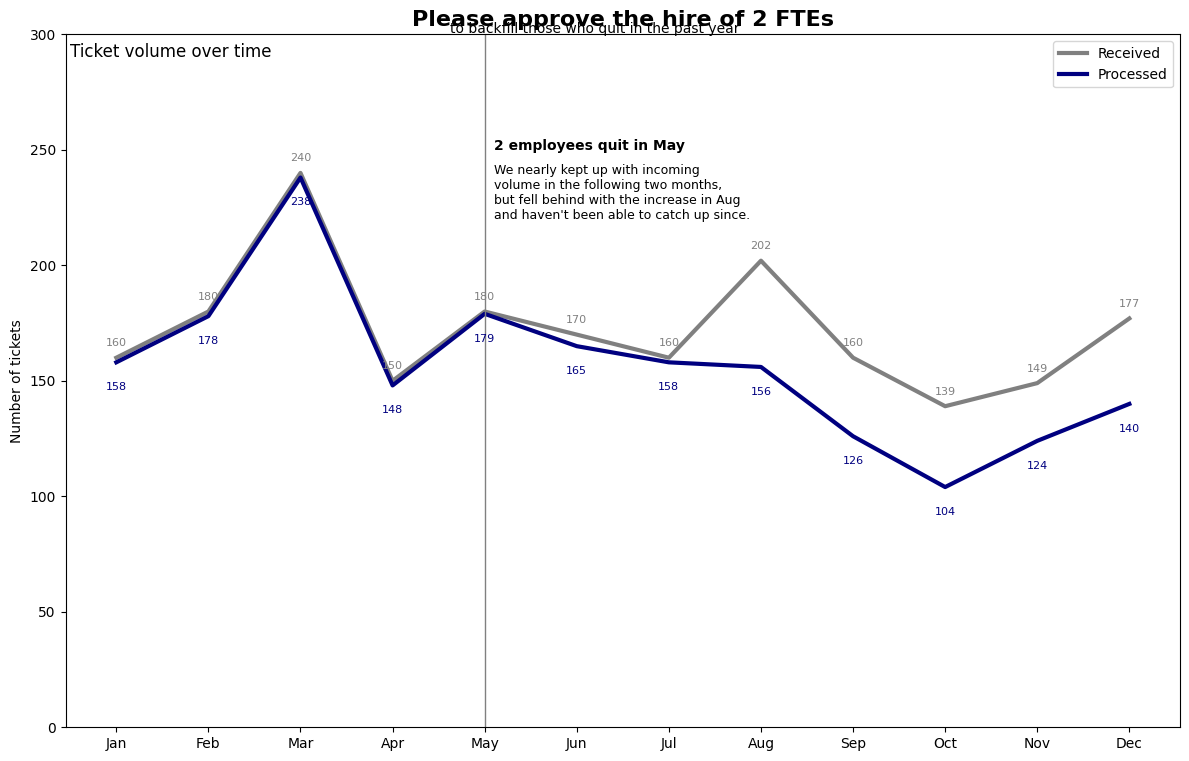

In [27]:
import matplotlib.pyplot as plt

# Months and labels
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
x = list(range(len(months)))

# Ticket volume data (approximated from image)
received = [160, 180, 240, 150, 180, 170, 160, 202, 160, 139, 149, 177]
processed = [158, 178, 238, 148, 179, 165, 158, 156, 126, 104, 124, 140]

# Create the plot
plt.figure(figsize=(12,8))

# Plot lines
plt.plot(x, received, label="Received", color="gray", linewidth=3)
plt.plot(x, processed, label="Processed", color="navy", linewidth=3)

# Annotate individual values
for i in range(len(x)):
    plt.text(x[i], received[i] + 5, str(received[i]), ha='center', color="gray", fontsize=8)
    plt.text(x[i], processed[i] - 12, str(processed[i]), ha='center', color="navy", fontsize=8)

# Add vertical line for when employees quit (May)
plt.axvline(x=4, color="gray", linestyle='-', linewidth=1)
plt.text(4.1, 250, "2 employees quit in May", fontsize=10, weight='bold')
plt.text(4.1, 220, "We nearly kept up with incoming\nvolume in the following two months,\nbut fell behind with the increase in Aug\nand haven't been able to catch up since.", fontsize=9)

# Title and subtitle
plt.title("Please approve the hire of 2 FTEs", fontsize=16, weight='bold')
plt.suptitle("to backfill those who quit in the past year", fontsize=10, y=0.93)
plt.text(-0.5, 290, "Ticket volume over time", fontsize=12)

# Formatting axes
plt.xticks(x, months)
plt.ylabel("Number of tickets")
plt.ylim(0, 300)
plt.legend()

# Improve layout
plt.tight_layout()
plt.show()